# Exercise 4: Autoregressive Image Modeling
## Submission date: 25\05\2026, 23:59.


<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
%config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [16]:
# Convert images from 0-1 to 0-255 (integers).
def discretize(sample):
    return (sample * 255).to(torch.long)

# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(), discretize])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

#pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


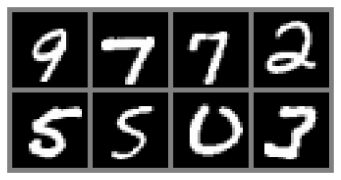

In [19]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=255)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

## Define Masked Cnvolutions

In [12]:
class MaskedConvolution(nn.Module):

    def __init__(self, c_in, c_out, mask, **kwargs):
        """
        Implements a convolution with mask applied on its weights.
        Inputs:
            c_in - Number of input channels
            c_out - Number of output channels
            mask - Tensor of shape [kernel_size_H, kernel_size_W] with 0s where
                   the convolution should be masked, and 1s otherwise.
            kwargs - Additional arguments for the convolution
        """
        super().__init__()
        # For simplicity: calculate padding automatically
        kernel_size = (mask.shape[0], mask.shape[1])

        # Actual convolution
        self.conv = nn.Conv2d(c_in, c_out, kernel_size, padding='same', **kwargs)

        # Mask as buffer => it is no parameter but still a tensor of the module
        # (must be moved with the devices)
        self.register_buffer('mask', mask[None,None].to(device))

    def forward(self, x):
        self.conv.weight.data *= self.mask # Ensures zero's at masked positions
        return self.conv(x)

In [13]:
class VerticalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels below. For efficiency, we could also reduce the kernel
        # size in height, but for simplicity, we stick with masking here.
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size//2+1:,:] = 0

        # For the very first convolution, we will also mask the center row
        if mask_center:
            mask[kernel_size//2,:] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

class HorizontalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        # Mask out all pixels on the left. Note that our kernel has a size of 1
        # in height because we only look at the pixel in the same row.
        mask = torch.ones(1,kernel_size)
        mask[0,kernel_size//2+1:] = 0

        # For the very first convolution, we will also mask the center pixel
        if mask_center:
            mask[0,kernel_size//2] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

In [4]:
def show_center_recep_field(img, out):
    """
    Calculates the gradients of the input with respect to the output center pixel,
    and visualizes the overall receptive field.
    Inputs:
        img - Input image for which we want to calculate the receptive field on.
        out - Output features/loss which is used for backpropagation, and should be
              the output of the network/computation graph.
    """
    # Determine gradients
    loss = out[0,:,img.shape[2]//2,img.shape[3]//2].sum() # L1 loss for simplicity
    loss.backward(retain_graph=True) # Retain graph as we want to stack multiple layers and show the receptive field of all of them
    img_grads = img.grad.abs()
    img.grad.fill_(0) # Reset grads

    # Plot receptive field
    img = img_grads.squeeze().cpu().numpy()
    fig, ax = plt.subplots(1,2)
    pos = ax[0].imshow(img)
    ax[1].imshow(img>0)
    # Mark the center pixel in red if it doesn't have any gradients (should be the case for standard autoregressive models)
    show_center = (img[img.shape[0]//2,img.shape[1]//2] == 0)
    if show_center:
        center_pixel = np.zeros(img.shape + (4,))
        center_pixel[center_pixel.shape[0]//2,center_pixel.shape[1]//2,:] = np.array([1.0, 0.0, 0.0, 1.0])
    for i in range(2):
        ax[i].axis('off')
        if show_center:
            ax[i].imshow(center_pixel)
    ax[0].set_title("Weighted receptive field")
    ax[1].set_title("Binary receptive field")
    plt.show()
    plt.close()

In [7]:
inp_img = torch.zeros(1, 1, 11, 11)
inp_img.requires_grad_()

tensor([[[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]]], requires_grad=True)

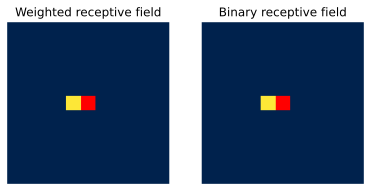

In [8]:
horiz_conv = HorizontalStackConvolution(c_in=1, c_out=1, kernel_size=3, mask_center=True).to(inp_img.device)
horiz_conv.conv.weight.data.fill_(1)
horiz_conv.conv.bias.data.fill_(0)
horiz_img = horiz_conv(inp_img)
show_center_recep_field(inp_img, horiz_img)

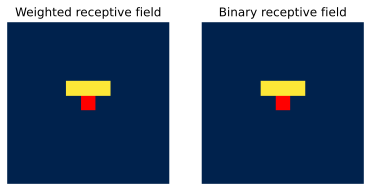

In [9]:
vert_conv = VerticalStackConvolution(c_in=1, c_out=1, kernel_size=3, mask_center=True).to(inp_img.device)
vert_conv.conv.weight.data.fill_(1)
vert_conv.conv.bias.data.fill_(0)
vert_img = vert_conv(inp_img)
show_center_recep_field(inp_img, vert_img)

In [10]:
del inp_img, horiz_conv, vert_conv

## PixelCNN without Gating and dilations

Instead of the GatedMaskConv from the tutorial, we defined a MaskedConvLayer for the model.

In [11]:
# class MaskedConvLayer(nn.Module):
#     def __init__(self, c_in,kernel_size=3, **kwargs):
#         """
#         Non Gated Convolution block implemented using the provided Vertical/Horizontal classes.
#         """
#         super().__init__()


#         # Internal layers use Mask Type B, which means the center pixel is NOT masked.
#         # Therefore, we set mask_center=False.
#         self.conv_v = VerticalStackConvolution(c_in, c_in, kernel_size=kernel_size, mask_center=False, **kwargs)
#         self.conv_h = HorizontalStackConvolution(c_in, c_in, kernel_size=kernel_size, mask_center=False, **kwargs)

#         # 1x1 convolution to pass information from the vertical stack to the horizontal stack
#         self.v_to_h = nn.Conv2d(c_in, c_in, kernel_size=1)

#     def forward(self, v_stack, h_stack):
#         # 1. Pass information through the vertical stack
#         v_out = self.conv_v(v_stack)

#         # 2. Pass information through the horizontal stack AND inject information from the vertical stack
#         h_out = self.conv_h(h_stack) + self.v_to_h(v_out)

#         v_out = F.elu(v_out)
#         h_out = F.elu(h_out)

#         # 4. Residual connection
#         return v_stack + v_out, h_stack + h_out


In [7]:
class MaskedConvLayer(nn.Module):
    # Added dropout_rate as an argument with a default value of 0.1
    def __init__(self, c_in, kernel_size=3, dropout_rate=0.1, **kwargs):
        """
        Non Gated Convolution block implemented using the provided Vertical/Horizontal classes.
        """
        super().__init__()

        # Internal layers use Mask Type B, which means the center pixel is NOT masked.
        # Therefore, we set mask_center=False.
        self.conv_v = VerticalStackConvolution(c_in, c_in, kernel_size=kernel_size, mask_center= False, **kwargs)
        self.conv_h = HorizontalStackConvolution(c_in, c_in, kernel_size=kernel_size, mask_center= False, **kwargs)

        # 1x1 convolution to pass information from the vertical stack to the horizontal stack
        self.v_to_h = nn.Conv2d(c_in, c_in, kernel_size=1)

        # Regularization layer (Dropout)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, v_stack, h_stack):
        # 1. Pass information through the vertical stack
        v_out = self.conv_v(v_stack)

        # 2. Pass information through the horizontal stack AND inject information from the vertical stack
        h_out = self.conv_h(h_stack) + self.v_to_h(v_out)

        # 3. Simple activation function (ELU)
        v_out = F.elu(v_out)
        h_out = F.elu(h_out)

        # Apply Dropout before the residual connection to prevent overfitting
        v_out = self.dropout(v_out)
        h_out = self.dropout(h_out)

        # 4. Residual connection (the original stack bypasses the dropout!)
        return v_stack + v_out, h_stack + h_out

In [8]:
class PixelCNN(nn.Module):

    def __init__(self, c_in, c_hidden, num_layers=7, kernel_size=3,dropout_rate=0.1, causal=True):
        super().__init__()
        # Removed self.save_hyperparameters() because we are not using Pytorch-Lightning

        # Initial convolutions skipping the center pixel (Mask Type A)
        self.conv_vstack = VerticalStackConvolution(c_in, c_hidden, mask_center=causal)
        self.conv_hstack = HorizontalStackConvolution(c_in, c_hidden, mask_center=causal)

        # Convolution block of PixelCNN.
        # Replaced GatedMaskedConv and Dilation with our simple MaskedConvLayer
        self.conv_layers = nn.ModuleList([
            MaskedConvLayer(c_hidden, kernel_size=kernel_size, dropout_rate=dropout_rate) for _ in range(num_layers)
        ])

        # Output classification convolution (1x1)
        self.conv_out = nn.Conv2d(c_hidden, c_in * 256, kernel_size=1, padding=0)

        # Removed self.example_input_array as it belongs to Lightning

    def forward(self, x):
        """
        Forward image through model and return logits for each pixel.
        Inputs:
            x - Image tensor with integer values between 0 and 255.
        """
        # Scale input from 0 to 255 back to -1 to 1
        x = (x.float() / 255.0) * 2 - 1

        # Initial convolutions
        v_stack = self.conv_vstack(x)
        h_stack = self.conv_hstack(x)

        # Other Convolutions
        for layer in self.conv_layers:
            v_stack, h_stack = layer(v_stack, h_stack)

        # === Critical fix for Section 1: Merging the stacks together ===
        combined = v_stack + h_stack

        # Apply ELU before 1x1 convolution for non-linearity on residual connection
        out = self.conv_out(F.elu(combined))

        # Output dimensions: [Batch, Classes, Channels, Height, Width]
        out = out.reshape(out.shape[0], 256, out.shape[1]//256, out.shape[2], out.shape[3])

        return out

    def calc_nll(self, x):
        """
        Calculates the Negative Log Likelihood in units of Bits Per Dimension (bpd).
        """
        # 1. Save the original image as class labels (0-255)
        # The cross_entropy function expects integers (long tensors)
        targets = x.long()

        # 2. Pass the image through the network to get the predictions (Logits)
        # (Note that our forward function automatically scales x to range [-1, 1] internally)
        logits = self.forward(x)

        # 3. Calculate the Loss function (Cross Entropy) for each pixel independently
        loss = F.cross_entropy(logits, targets, reduction='none')

        # 4. Convert from Nats (natural logarithm used by PyTorch) to Bits (base 2 logarithm)
        bpd = loss / math.log(2)

        # 5. Return the mean across all pixels and images in the batch
        return bpd.mean()

    @torch.no_grad()
    def sample(self, img_shape, img=None):
        """
        Sampling function for the autoregressive model.
        Inputs:
            img_shape - Shape of the image to generate (B,C,H,W)
            img (optional) - If given, this tensor will be used as
                             a starting image. The pixels to fill
                             should be -1 in the input tensor.
        """
        # Create empty image
        if img is None:
            # Minor fix: Use the model's device to prevent CPU/GPU crashes
            img = torch.zeros(img_shape, dtype=torch.long).to(self.conv_out.weight.device) - 1

        # Generation loop
        for h in tqdm(range(img_shape[2]), leave=False):
            for w in range(img_shape[3]):
                for c in range(img_shape[1]):
                    # Skip if not to be filled (-1)
                    if (img[:,c,h,w] != -1).all().item():
                        continue
                    # For efficiency, we only have to input the upper part of the image
                    # as all other parts will be skipped by the masked convolutions anyways
                    pred = self.forward(img[:,:,:h+1,:])
                    probs = F.softmax(pred[:,:,c,h,w], dim=-1)
                    img[:,c,h,w] = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
        return img

Before you start training, you have to choose hyper-parameters for your model (e.g. number of layers).

We can check the full receptive field of the model on an MNIST image of size $28\times 28$ to help you decide which hyper-parameters to use:

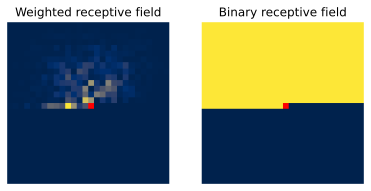

In [14]:
test_model = PixelCNN(c_in=1, c_hidden=128,  num_layers=7, kernel_size=7).to('cpu')      # adjust according to your model
inp = torch.zeros(1,1,28,28).to('cpu')                    # do not remove the 'cpu' here
inp.requires_grad_()
out = test_model(inp)
show_center_recep_field(inp, out.squeeze(dim=2))
del inp, out, test_model

## Model Training

In [15]:
#model = PixelCNN(c_in=1, c_hidden=64,  num_layers=2, kernel_size=15) # adjust according to your model
#print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

#model = torch.compile(model.to(device))

#optimizer = optim.Adam(model.parameters(), lr=1e-3)
#scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
#epochs = 10


In [16]:
# Training loop
#train_bpd = []
#val_bpd = []

#for epoch in range(epochs):
#    model.train()
#    losses = []
#
#    for imgs, _ in tqdm(train_loader, leave=False):
#        imgs = imgs.to(device)
#        optimizer.zero_grad()
#        loss = model.calc_nll(imgs)
#        loss.backward()
#        optimizer.step()
#        losses.append(loss.item())
#
#    train_bpd.append(np.mean(losses))
#    scheduler.step()
#
#    losses = []
#    with torch.no_grad():
#      for imgs, _ in tqdm(val_loader, leave=False):
#          imgs = imgs.to(device)
#          loss = model.calc_nll(imgs)
#          losses.append(loss.item())
#
#    val_bpd.append(np.mean(losses))
#
#    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_bpd[-1]:.4f}, Val Loss: {val_bpd[-1]:.4f}")
#
#    if (epoch + 1) % 2 == 0:
#       sampled_images = model.sample(img_shape=(4, 1, 28, 28))
#       show_imgs(sampled_images)
#
## Test loop
#model.eval()
#losses = []
#for imgs, _ in tqdm(test_loader, leave=False):
#    imgs = imgs.to(device)
#    loss = model.calc_nll(imgs)
#    losses.append(loss.item())
#
#test_bpd = np.mean(losses)
#print(f"Test Loss: {test_bpd:.4f}")




---


> ### **Question 1**



---



In [ ]:
model = PixelCNN(c_in=1, c_hidden=128,  num_layers=7, kernel_size=7) 
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

# 1. Added weight_decay (L2 Regularization) to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# 2. Smart Scheduler: Drops LR by half if validation loss stops improving for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


Num params: 6,574,720


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/30 | LR: 0.000250 | Train Loss: 0.9402 | Val Loss: 0.9106 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/30 | LR: 0.000250 | Train Loss: 0.9286 | Val Loss: 0.9075 <-- New Best Model Saved!

[Epoch 2] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

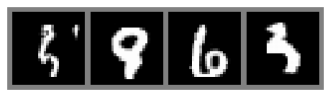

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/30 | LR: 0.000250 | Train Loss: 0.9290 | Val Loss: 0.9009 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4/30 | LR: 0.000250 | Train Loss: 0.9232 | Val Loss: 0.8986 <-- New Best Model Saved!

[Epoch 4] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

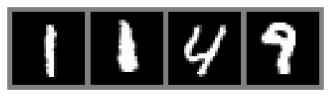

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5/30 | LR: 0.000250 | Train Loss: 0.9188 | Val Loss: 0.8851 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 6/30 | LR: 0.000250 | Train Loss: 0.9080 | Val Loss: 0.8868

[Epoch 6] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

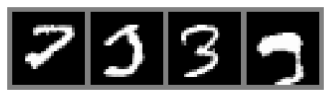

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 7/30 | LR: 0.000250 | Train Loss: 0.9097 | Val Loss: 0.8793 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 8/30 | LR: 0.000250 | Train Loss: 0.9031 | Val Loss: 0.8747 <-- New Best Model Saved!

[Epoch 8] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

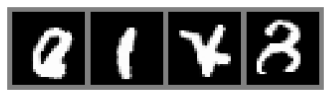

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/30 | LR: 0.000250 | Train Loss: 0.9009 | Val Loss: 0.8873


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/30 | LR: 0.000250 | Train Loss: 0.8972 | Val Loss: 0.9275

[Epoch 10] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

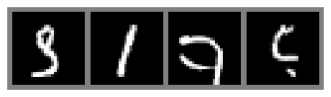

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/30 | LR: 0.000125 | Train Loss: 0.8928 | Val Loss: 0.8780


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 12/30 | LR: 0.000125 | Train Loss: 0.8763 | Val Loss: 0.8591 <-- New Best Model Saved!

[Epoch 12] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

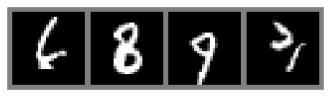

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 13/30 | LR: 0.000125 | Train Loss: 0.8707 | Val Loss: 0.8554 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/30 | LR: 0.000125 | Train Loss: 0.8670 | Val Loss: 0.8536 <-- New Best Model Saved!

[Epoch 14] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

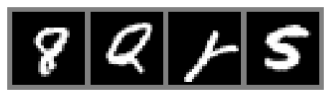

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/30 | LR: 0.000125 | Train Loss: 0.8639 | Val Loss: 0.8498 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/30 | LR: 0.000125 | Train Loss: 0.8617 | Val Loss: 0.8481 <-- New Best Model Saved!

[Epoch 16] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

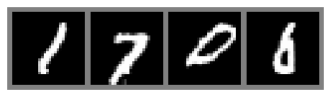

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 17/30 | LR: 0.000125 | Train Loss: 0.8592 | Val Loss: 0.8455 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 18/30 | LR: 0.000125 | Train Loss: 0.8566 | Val Loss: 0.8453 <-- New Best Model Saved!

[Epoch 18] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

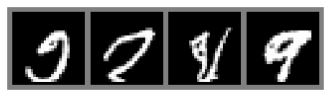

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/30 | LR: 0.000125 | Train Loss: 0.8542 | Val Loss: 0.8421 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/30 | LR: 0.000125 | Train Loss: 0.8525 | Val Loss: 0.8401 <-- New Best Model Saved!

[Epoch 20] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

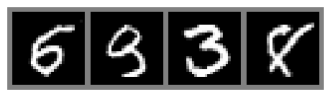

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 21/30 | LR: 0.000125 | Train Loss: 0.8512 | Val Loss: 0.8391 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 22/30 | LR: 0.000125 | Train Loss: 0.8494 | Val Loss: 0.8386 <-- New Best Model Saved!

[Epoch 22] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

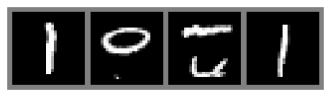

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 23/30 | LR: 0.000125 | Train Loss: 0.8480 | Val Loss: 0.8353 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/30 | LR: 0.000125 | Train Loss: 0.8459 | Val Loss: 0.8364

[Epoch 24] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

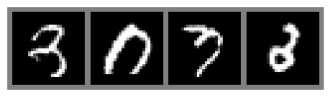

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/30 | LR: 0.000125 | Train Loss: 0.8447 | Val Loss: 0.8357


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 26/30 | LR: 0.000125 | Train Loss: 0.8430 | Val Loss: 0.8327 <-- New Best Model Saved!

[Epoch 26] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

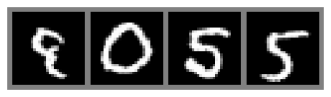

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 27/30 | LR: 0.000125 | Train Loss: 0.8417 | Val Loss: 0.8303 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 28/30 | LR: 0.000125 | Train Loss: 0.8403 | Val Loss: 0.8309

[Epoch 28] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

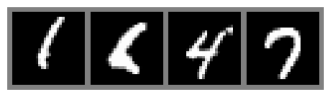

Done sampling.



  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 29/30 | LR: 0.000125 | Train Loss: 0.8390 | Val Loss: 0.8298 <-- New Best Model Saved!


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30/30 | LR: 0.000125 | Train Loss: 0.8383 | Val Loss: 0.8287 <-- New Best Model Saved!

[Epoch 30] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

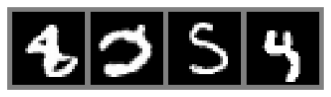

Done sampling.



In [27]:
epochs = 30 # Can increase a bit because the scheduler will handle convergence safely

# Training loop
train_bpd = []
val_bpd = []

# === תוספת: שמירת הציון הטוב ביותר כדי לא לאבד את המודל ===
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    losses = []

    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.calc_nll(imgs)
        loss.backward()

        # Prevents exploding gradients which are common in autoregressive models
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        losses.append(loss.item())

    train_bpd.append(np.mean(losses))


    # Validation loop
    model.eval() # Important to set to eval mode for validation
    losses = []
    with torch.no_grad():
        for imgs, _ in tqdm(val_loader, leave=False):
            imgs = imgs.to(device)
            loss = model.calc_nll(imgs)
            losses.append(loss.item())

    current_val_loss = np.mean(losses)
    val_bpd.append(current_val_loss)

    # === תוספת: שמירת המודל הטוב ביותר (Checkpointing) ===
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), "best_pixelcnn.pt")
        saved_msg = " <-- New Best Model Saved!"
    else:
        saved_msg = ""

    # === IMPROVEMENT: Step the smart scheduler based on Validation Loss ===
    scheduler.step(val_bpd[-1])

    # Print current learning rate along with the losses
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Loss: {train_bpd[-1]:.4f} | Val Loss: {val_bpd[-1]:.4f}{saved_msg}")

    # === תיקון: שינוי epochs_q2 ל-epochs הרגיל ===
    if (epoch + 1) % 2 == 0 or (epoch + 1) == epochs:
        print(f"\n[Epoch {epoch+1}] Generating intermediate samples...")
        model.eval()
        with torch.no_grad():
            sampled_images = model.sample(img_shape=(4, 1, 28, 28))
            show_imgs(sampled_images)
        print("Done sampling.\n")

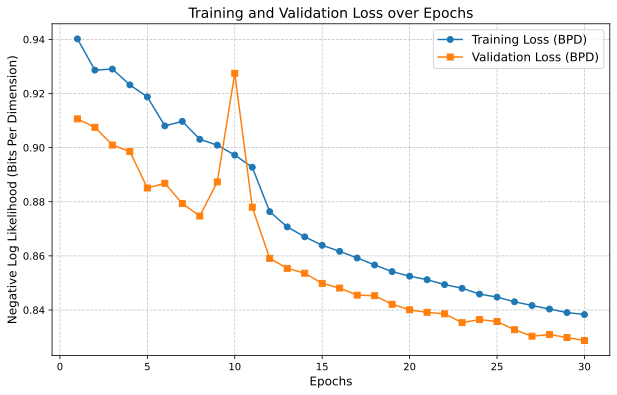

In [28]:
# Plotting the negative log likelihoods (in BPD) for training and validation
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_bpd, label='Training Loss (BPD)', marker='o')
plt.plot(range(1, epochs + 1), val_bpd, label='Validation Loss (BPD)', marker='s')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Negative Log Likelihood (Bits Per Dimension)', fontsize=12)
plt.title('Training and Validation Loss over Epochs', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Generating 16 samples from the trained model...


  0%|          | 0/28 [00:00<?, ?it/s]

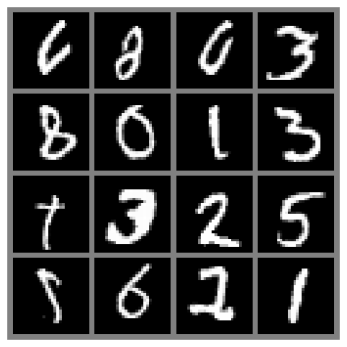

In [35]:
# Generate 16 new samples from the model (4x4 grid)
print("Generating 16 samples from the trained model...")
sampled_images = model.sample(img_shape=(16, 1, 28, 28))
show_imgs(sampled_images)



---



> ### **Question 2**


---



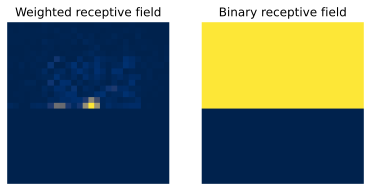

In [ ]:
test_model = PixelCNN(c_in=1, c_hidden=128,  num_layers=2, kernel_size=15, causal=False).to('cpu')      # adjust according to your model
inp = torch.zeros(1,1,28,28).to('cpu')                    # do not remove the 'cpu' here
inp.requires_grad_()
out = test_model(inp)
show_center_recep_field(inp, out.squeeze(dim=2))
del inp, out, test_model

In [ ]:
# 1. Disable dropout so the model can perfectly learn the identity shortcut
model_not_causal = PixelCNN(c_in=1, c_hidden=64, num_layers=2, kernel_size=17, dropout_rate=0.0, causal=False).to(device)

# 2. FIXED TYPO: changed 'model' to 'model_not_causal'
print("Num params: {:,}".format(sum(p.numel() for p in model_not_causal.parameters())))

# (Optional: torch.compile makes it faster on PyTorch 2.0+, it's fine to keep it if it doesn't throw errors for you)
model_not_causal = torch.compile(model_not_causal)

# 3. Optimizer for the NON-CAUSAL model
optimizer_not_causal = optim.Adam(model_not_causal.parameters(), lr=1e-3, weight_decay=1e-5)

# 4. Smart Scheduler
scheduler_not_causal = optim.lr_scheduler.ReduceLROnPlateau(optimizer_not_causal, mode='min', factor=0.5, patience=2)

epochs_q2 = 20

Num params: 2,532,864


Epoch 1 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/20 | LR: 0.001000 | Train Loss: 1.2045 | Val Loss: 0.7784


Epoch 2 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 2 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/20 | LR: 0.001000 | Train Loss: 0.7261 | Val Loss: 0.6771

[Epoch 2] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

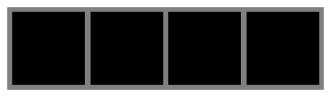

Done sampling.



Epoch 3 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 3 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/20 | LR: 0.001000 | Train Loss: 0.6588 | Val Loss: 0.6277


Epoch 4 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 4 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4/20 | LR: 0.001000 | Train Loss: 0.6201 | Val Loss: 0.6219

[Epoch 4] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

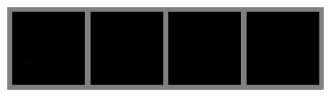

Done sampling.



Epoch 5 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 5 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5/20 | LR: 0.001000 | Train Loss: 0.5936 | Val Loss: 0.5864


Epoch 6 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 6 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 6/20 | LR: 0.001000 | Train Loss: 0.5642 | Val Loss: 0.5406

[Epoch 6] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

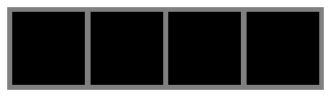

Done sampling.



Epoch 7 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 7 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 7/20 | LR: 0.001000 | Train Loss: 0.5625 | Val Loss: 0.5038


Epoch 8 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 8 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 8/20 | LR: 0.001000 | Train Loss: 0.5412 | Val Loss: 0.4935

[Epoch 8] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

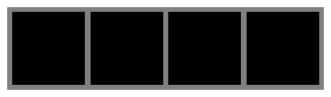

Done sampling.



Epoch 9 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 9 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/20 | LR: 0.001000 | Train Loss: 0.5363 | Val Loss: 0.8064


Epoch 10 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 10 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/20 | LR: 0.001000 | Train Loss: 0.5243 | Val Loss: 0.5625

[Epoch 10] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

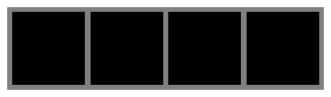

Done sampling.



Epoch 11 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 11 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/20 | LR: 0.001000 | Train Loss: 0.5063 | Val Loss: 0.4478


Epoch 12 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 12 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 12/20 | LR: 0.001000 | Train Loss: 0.4913 | Val Loss: 0.4649

[Epoch 12] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

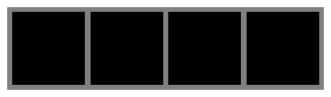

Done sampling.



Epoch 13 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 13 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 13/20 | LR: 0.001000 | Train Loss: 0.4939 | Val Loss: 0.4732


Epoch 14 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 14 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/20 | LR: 0.001000 | Train Loss: 0.4901 | Val Loss: 0.4293

[Epoch 14] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

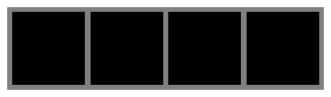

Done sampling.



Epoch 15 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 15 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/20 | LR: 0.001000 | Train Loss: 0.4654 | Val Loss: 0.4198


Epoch 16 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 16 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 16/20 | LR: 0.001000 | Train Loss: 0.4823 | Val Loss: 0.4589

[Epoch 16] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

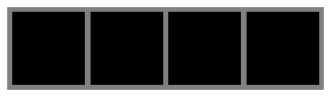

Done sampling.



Epoch 17 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 17 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 17/20 | LR: 0.001000 | Train Loss: 0.4637 | Val Loss: 0.7456


Epoch 18 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 18 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 18/20 | LR: 0.000500 | Train Loss: 0.4653 | Val Loss: 0.4726

[Epoch 18] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

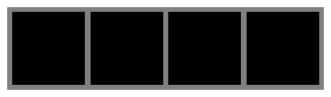

Done sampling.



Epoch 19 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 19 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/20 | LR: 0.000500 | Train Loss: 0.3879 | Val Loss: 0.3507


Epoch 20 Train:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 20 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 | LR: 0.000500 | Train Loss: 0.3778 | Val Loss: 0.4011

[Epoch 20] Generating intermediate samples...


  0%|          | 0/28 [00:00<?, ?it/s]

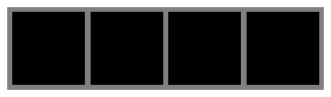

Done sampling.



In [ ]:
# Training loop for the NON-CAUSAL model
train_bpd = []
val_bpd = []

for epoch in range(epochs_q2): # שים לב: השתמשנו ב-epochs_q2 או epochs, תלוי איך הגדרת
    model_not_causal.train()
    losses = []

    for imgs, _ in tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1} Train"):
        imgs = imgs.to(device)

        # השתמשנו באופטימייזר של המודל הלא-סיבתי
        optimizer_not_causal.zero_grad()

        loss = model_not_causal.calc_nll(imgs)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model_not_causal.parameters(), max_norm=1.0)

        optimizer_not_causal.step()
        losses.append(loss.item())

    train_bpd.append(np.mean(losses))

    # Validation loop
    model_not_causal.eval()
    losses = []
    with torch.no_grad():
        for imgs, _ in tqdm(val_loader, leave=False, desc=f"Epoch {epoch+1} Val"):
            imgs = imgs.to(device)
            loss = model_not_causal.calc_nll(imgs)
            losses.append(loss.item())

    val_bpd.append(np.mean(losses))

    # Smart scheduler step
    scheduler_not_causal.step(val_bpd[-1])

    # Print current learning rate along with the losses
    current_lr = optimizer_not_causal.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs_q2} | LR: {current_lr:.6f} | Train Loss: {train_bpd[-1]:.4f} | Val Loss: {val_bpd[-1]:.4f}")

    # ==========================================
    # תוספת ה-Sampling במהלך האימון
    # נייצר תמונות כל 2 אופוקים, וגם באופוק האחרון
    # ==========================================
    if (epoch + 1) % 2 == 0 or (epoch + 1) == epochs_q2:
        print(f"\n[Epoch {epoch+1}] Generating intermediate samples...")
        model_not_causal.eval()
        with torch.no_grad():
            # נייצר 4 תמונות כדי לחסוך קצת זמן ריצה
            sampled_images_not_causal = model_not_causal.sample(img_shape=(4, 1, 28, 28))

            # בהנחה שיש לך פונקציה show_imgs זמינה במחברת
            # (אם לא, תצטרך להוסיף אותה, לרוב זה matplotlib)
            show_imgs(sampled_images_not_causal)
        print("Done sampling.\n")

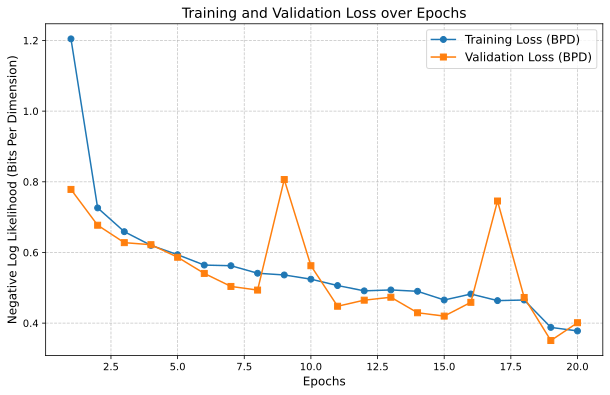

In [ ]:
# Plotting the negative log likelihoods (in BPD) for training and validation
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_bpd, label='Training Loss (BPD)', marker='o')
plt.plot(range(1, epochs + 1), val_bpd, label='Validation Loss (BPD)', marker='s')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Negative Log Likelihood (Bits Per Dimension)', fontsize=12)
plt.title('Training and Validation Loss over Epochs', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Generating 16 samples from the trained model...


  0%|          | 0/28 [00:00<?, ?it/s]

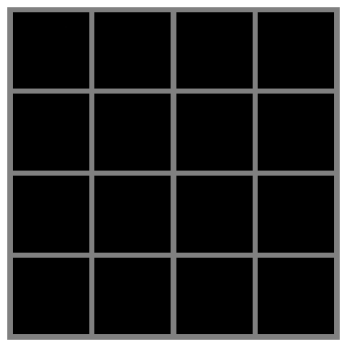

In [ ]:
# Generate 16 new samples from the model (4x4 grid)
print("Generating 16 samples from the trained model...")
sampled_images = model_not_causal.sample(img_shape=(16, 1, 28, 28))
show_imgs(sampled_images)

As expected, the non-causal model fails to generate valid digits. Interestingly, instead of outputting random noise, the model outputs completely black images. This is because the model learned the identity mapping $f(x) = x$. During sampling, the uninitialized pixels (set to -1) are scaled to approximately -1.0 in the forward pass. This value is nearly identical to the scaled value of a black pixel (0 scales to -1.0).
Consequently, the identity model interprets the 'empty' canvas as black pixels and perfectly copies them to the output, resulting in a completely black generation.


### Why Does the Loss Drop to Zero if the Model Can't Generate Anything?

This highlights the critical difference between how autoregressive models are **trained** versus how they are **sampled**. 

You are right that if the model cannot generate an image, the loss *should* be high. However, the catch is that **the model does not generate images during training.** 

Here is exactly why the cross-entropy loss drops to nearly zero when the convolutions are non-causal:

#### 1. Training uses "Teacher Forcing"
During training, we do not generate the image pixel-by-pixel. Instead, we feed the **entire, complete ground-truth image** into the model all at once. 

The model's task is to output a probability distribution for every single pixel simultaneously. The loss is calculated by comparing the model's prediction at position $i$ against the actual ground-truth value at position $i$. 

If the model is **non-causal** (meaning it is allowed to see the pixel it is trying to predict), the neuron responsible for predicting pixel $i$ simply looks at the input channel for pixel $i$ and says: *"Ah, the input here is a gray value of 142. Therefore, I will output a 100% probability that this pixel is 142."*

Because its prediction matches the ground truth perfectly, the Cross-Entropy loss evaluates this as a perfect prediction, and the loss drops to zero. The model successfully "cheated" the training objective.

#### 2. Sampling has no Ground Truth
When training is over and we actually want to generate an image (inference/sampling), the environment completely changes. 

We no longer have a ground-truth image to feed the model. We have to start with a blank canvas (a tensor of zeros or noise) and generate it pixel-by-pixel. 

When we ask our "cheating" model to predict the first pixel, it looks at the blank canvas. Because it learned the identity function ($f(x) = x$), it looks at the input (a blank pixel), and confidently predicts that the output should also be a blank pixel. It moves to the next pixel, sees a blank pixel, and outputs a blank pixel again. 

#### The Takeaway
The Cross-Entropy loss only measures how well the model predicts the target **based on the inputs it is given during training**. 

If you give the model the answer key (by making it non-causal), it will score 100% on the test without actually learning the material. Causal masking is the physical mechanism that forces the model to actually learn the statistical relationships between pixels, rather than just memorizing the cheat sheet.





---



> ### Question 3




---



In [9]:
import os
import urllib.request
from urllib.error import HTTPError
import torch

In [14]:
# 1. Define the path to YOUR locally trained model
file_path = "./best_pixelcnn.pt" # Change to your actual path if needed

# Check if the file exists
if not os.path.isfile(file_path):
    raise FileNotFoundError(f"Could not find the model file at {file_path}")

# 2. Create a fresh instance of our network
pretrained_model = PixelCNN(c_in=1, c_hidden=128, num_layers=7, kernel_size=7).to(device)

# 3. Load the raw weights from the disk (added weights_only=True to silence the warning)
state_dict = torch.load(file_path, map_location=device, weights_only=True)

# 4. --- THE FIX: Clean the '_orig_mod.' prefix caused by torch.compile() ---
cleaned_state_dict = {}
for key, value in state_dict.items():
    clean_key = key.replace("_orig_mod.", "")
    cleaned_state_dict[clean_key] = value

# 5. Load the cleaned weights into the model
pretrained_model.load_state_dict(cleaned_state_dict)

# 6. CRITICAL: Switch the model to evaluation mode
pretrained_model.eval()

print("Your custom trained model loaded successfully and is ready to use!")

Your custom trained model loaded successfully and is ready to use!


___
## a. The marginal probability of the first pixel
___

# PixelCNN: Marginal Probability of the First Pixel

## Overview
This section addresses the evaluation of the marginal probability for the very first pixel in the generation sequence—the top-left pixel located at spatial coordinate `(h=0, w=0)`. Calculating this probability, $P(x_1)$, is natively supported and represents the most straightforward inference operation in a PixelCNN.

## 1. Theoretical Foundation (Unconditioned Generation)
In an autoregressive generative model, the joint probability of an image is factorized via the chain rule: $P(X) = \prod P(x_i \mid x_{<i})$. 

For the very first pixel in the sequence, $x_1$, the set of preceding pixels $x_{<1}$ is entirely empty. Therefore, its prediction cannot be conditioned on any context. The model must output a pure marginal probability distribution, $P(x_1)$, which represents the global prior for the first pixel learned directly from the overall training dataset.

## 2. Architectural Mechanism (Mask Type A)
This unconditioned property is strictly enforced by the model's architecture—specifically through the utilization of **Mask Type A** in the initial convolutional layer. 

Mask Type A explicitly zeroes out the center pixel (and all subsequent pixels) in the receptive field. When evaluating the spatial coordinate `(0,0)`, the mask physically prevents any information from the current pixel, or any future pixels, from flowing into the calculation. The hidden state at this location relies entirely on the learned biases and weights of the network.

## 3. Key Insight: Input Independence
Because the network is mathematically "blind" to the input when predicting this initial pixel, the actual input tensor provided to the forward pass is completely irrelevant. 

Whether you pass a real MNIST digit, a tensor of all zeros, or pure random noise, the network's output logits at coordinate `(0,0)` will remain mathematically identical. The probability distribution is entirely fixed by the model's trained parameters.

The most likely value for the first pixel is 0 with probability 0.99996888638


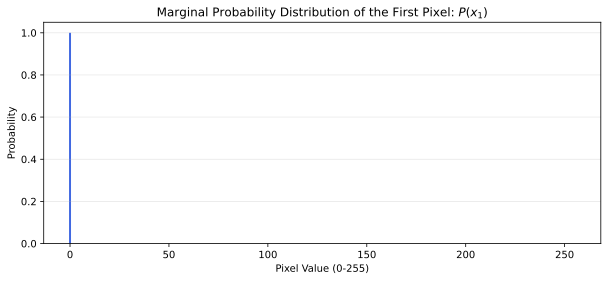

In [44]:
@torch.no_grad()
def plot_marginal_prob_first_pixel(model, device):
    # Ensure the model is in evaluation mode
    model.eval()

    # 1. Create a dummy image (values do not matter due to Mask Type A)
    # Dimensions: [Batch=1, Channels=1, Height=28, Width=28]
    dummy_img = torch.zeros((1, 1, 28, 28), dtype=torch.float32).to(device)

    # 2. Pass the image through the model
    logits = model(dummy_img) # Output shape: [1, 256, 1, 28, 28]

    # 3. Extract the logits for the very first pixel only (h=0, w=0)
    # Selecting: batch 0, all 256 classes, channel 0, row 0, col 0
    first_pixel_logits = logits[0, :, 0, 0, 0]

    # 4. Convert logits to probabilities using Softmax
    probs = F.softmax(first_pixel_logits, dim=-1).cpu().numpy()

    # 5. Plot the probability distribution
    plt.figure(figsize=(10, 4))
    plt.bar(range(256), probs, color='royalblue', width=1.0)
    plt.title("Marginal Probability Distribution of the First Pixel: $P(x_1)$")
    plt.xlabel("Pixel Value (0-255)")
    plt.ylabel("Probability")
    plt.grid(axis='y', alpha=0.3)

    # Print the most likely value
    most_likely_val = probs.argmax()
    print(f"The most likely value for the first pixel is {most_likely_val} with probability {probs[most_likely_val]:.11f}")

    plt.show()

# Run the function on your pretrained model
plot_marginal_prob_first_pixel(pretrained_model, device)

___
## b) The marginal probability of the middle pixel (pixel 14, 14).
___

# PixelCNN: Approximating Marginal Probability

## Overview
This section addresses the evaluation of the marginal probability of a target pixel deep within the image sequence—specifically, the middle pixel at coordinates `(14, 14)`. Because the model naturally outputs conditional probabilities, computing this exact marginal distribution presents a significant computational challenge.

## 1. Theoretical Limitation (Intractability)
Autoregressive models like PixelCNN are inherently designed to model and output *conditional* probabilities: $P(x_i \mid x_{<i})$. 

To calculate the exact *marginal* probability of the middle pixel, $P(x_{14, 14})$, one must marginalize (sum) over every possible permutation of all preceding pixels in the generation sequence. The middle pixel is located at the flattened index $14 \times 28 + 14 = 406$. Since each of the prior $406$ pixels can take $256$ possible intensity values (0–255), exact marginalization requires computing the sum of $256^{406}$ individual terms:

$$P(x_{406}) = \sum_{x_1} \sum_{x_2} \dots \sum_{x_{405}} P(x_1, \dots, x_{406})$$

This state space is astronomically large, making the exact mathematical computation strictly intractable.

## 2. The Approximation Method (Monte Carlo Sampling)
Because computing the exact sum is impossible, the expected value can be mathematically approximated using **Monte Carlo Sampling**.

Instead of summing over *all* possible prefixes, we utilize the model to autoregressively generate (sample) a discrete batch of $N$ valid image prefixes (generating pixels from the top-left up to the target middle pixel). For each sampled prefix, the model natively provides a conditional distribution for the middle pixel: $P(x_{14,14} \mid \text{sampled context})$.

By the Law of Large Numbers, averaging these conditional distributions across our $N$ generated samples yields a robust approximation of the true marginal distribution:

$$P(x_{14,14}) \approx \frac{1}{N} \sum_{i=1}^N P(x_{14,14} \mid x_{<14,14}^{(i)})$$

Sampling context:   0%|          | 0/15 [00:00<?, ?it/s]

Approximated most likely value: 0 (Prob: 0.27488264441)


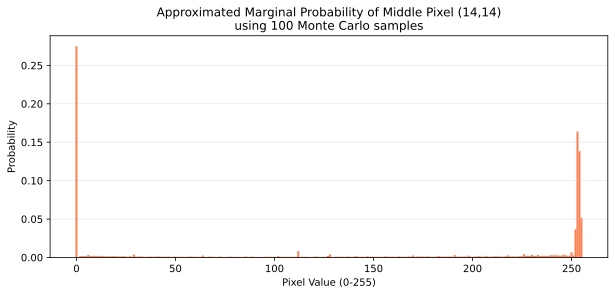

In [45]:
@torch.no_grad()
def approximate_marginal_middle_pixel(model, device, num_samples=32):
    model.eval()

    # 1. Initialize an empty canvas for a batch of samples
    img = torch.zeros((num_samples, 1, 28, 28), dtype=torch.long).to(device) - 1

    target_h, target_w = 14, 14

    # 2. Autoregressively sample pixels ONLY up to the middle pixel
    for h in tqdm(range(target_h + 1), desc="Sampling context"):
        for w in range(28):
            # Stop right before evaluating the middle pixel
            if h == target_h and w >= target_w:
                break

            # Forward pass to predict the current pixel based on context
            pred = model(img[:, :, :h+1, :])
            probs = F.softmax(pred[:, :, 0, h, w], dim=-1)

            # Sample a color and update the canvas
            img[:, 0, h, w] = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)

    # 3. With the context generated, predict the distribution for the middle pixel
    pred = model(img)
    middle_pixel_logits = pred[:, :, 0, target_h, target_w]

    # 4. Get conditional probabilities for each sample in the batch
    conditional_probs = F.softmax(middle_pixel_logits, dim=-1) # Shape: [num_samples, 256]

    # 5. Monte Carlo Approximation: Average the probabilities across the batch
    marginal_prob_approx = conditional_probs.mean(dim=0).cpu().numpy() # Shape: [256]

    # 6. Plot the approximated distribution
    plt.figure(figsize=(10, 4))
    plt.bar(range(256), marginal_prob_approx, color='coral', width=1.0)
    plt.title(f"Approximated Marginal Probability of Middle Pixel (14,14)\nusing {num_samples} Monte Carlo samples")
    plt.xlabel("Pixel Value (0-255)")
    plt.ylabel("Probability")
    plt.grid(axis='y', alpha=0.3)

    most_likely_val = marginal_prob_approx.argmax()
    print(f"Approximated most likely value: {most_likely_val} (Prob: {marginal_prob_approx[most_likely_val]:.11f})")

    plt.show()

    return marginal_prob_approx

# Run the approximation using the pretrained model
# (You can lower num_samples to 16 if your machine is running slowly)
approx_dist = approximate_marginal_middle_pixel(pretrained_model, device, num_samples=100)

___
## c) The conditional probability of the middle pixel, given the values of all pixels above and to the left of it.
___

# PixelCNN: Native Conditional Probability Inference

## Overview
This section addresses the evaluation of the conditional probability of a target pixel given the exact context of all preceding pixels (e.g., $P(x_{14,14} \mid x_{<14,14})$). 

Unlike computing marginal probabilities, which requires computationally expensive techniques like Monte Carlo sampling, computing this specific conditional probability is **native to the model** and mathematically straightforward.

## 1. Theoretical Foundation
This operation represents exactly what the PixelCNN architecture is built to perform out-of-the-box. The fundamental equation governing any autoregressive generative model is the probabilistic chain rule:

$$P(\text{Image}) = \prod_{i=1}^{N} P(x_i \mid x_{<i})$$

By design, the model is optimized to directly output these conditional distributions at every spatial location simultaneously.

## 2. Architectural Mechanism
Due to the implementation of masked convolutions (specifically **Mask Type B** in the hidden layers), the network's receptive field at any spatial location—such as the middle pixel at $(14, 14)$—is strictly limited to the pixels topologically above it and to its left in the current row. 

Because the architecture strictly enforces this causal constraint, the model's raw output at that specific spatial coordinate is exactly the conditional probability distribution requested. The network performs all the necessary conditional logic natively within its weights.

## 3. Practical Implementation
To calculate this probability, no iterative loops or approximation methods (like Monte Carlo sampling) are necessary. The procedure requires only a single forward pass:

1. **Context Initialization:** Provide a real image from the dataset to serve as the context (supplying the exact "given values of all pixels above and to the left").
2. **Forward Pass:** Pass the image through the network once.
3. **Extraction:** Extract the output logits at the target spatial location `(14, 14)`.
4. **Probability Conversion:** Apply a Softmax function to obtain the exact probability distribution.

Given the context, the model gives the highest probability (0.9506) to color 0.
The actual true color in the image was 0.


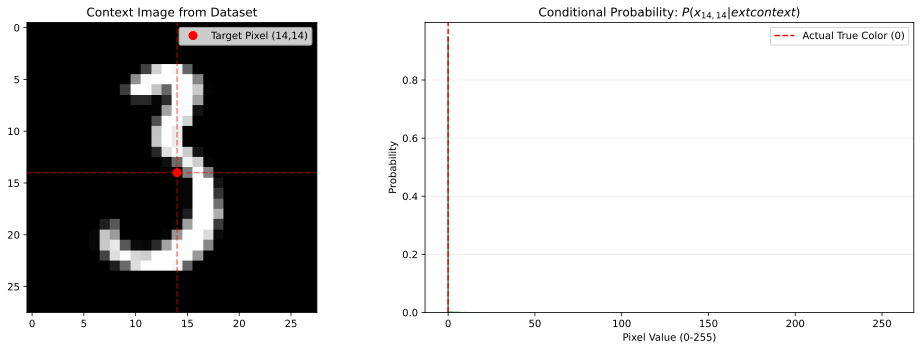

In [ ]:
@torch.no_grad()
def plot_conditional_prob_middle_pixel(model, dataloader, device):
    model.eval()

    # 1. Grab a single real image from the dataset to act as our context
    imgs, _ = next(iter(dataloader))
    real_img = imgs[0:1].to(device) # Shape: [1, 1, 28, 28]

    # 2. Get the actual color value of the middle pixel in this image
    # (So we can see if the model guessed it right!)
    actual_middle_color = real_img[0, 0, 14, 14].item()

    # 3. Single forward pass through the network
    logits = model(real_img)

    # 4. Extract the logits specifically for the middle pixel (h=14, w=14)
    middle_pixel_logits = logits[0, :, 0, 14, 14]

    # 5. Convert to probabilities
    probs = F.softmax(middle_pixel_logits, dim=-1).cpu().numpy()

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Show the image and highlight the middle pixel
    ax1.imshow(real_img[0, 0].cpu().numpy(), cmap='gray')
    ax1.axhline(y=14, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(x=14, color='red', linestyle='--', alpha=0.5)
    ax1.plot(14, 14, 'ro', markersize=8, label="Target Pixel (14,14)")
    ax1.set_title("Context Image from Dataset")
    ax1.legend()

    # Plot 2: Show the conditional probability distribution
    ax2.bar(range(256), probs, color='mediumseagreen', width=1.0)
    ax2.axvline(x=actual_middle_color, color='red', linestyle='--', label=f'Actual True Color ({int(actual_middle_color)})')
    ax2.set_title(f"Conditional Probability: $P(x_{{14,14}} | \text{{context}})$")
    ax2.set_xlabel("Pixel Value (0-255)")
    ax2.set_ylabel("Probability")
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    most_likely_val = probs.argmax()
    print(f"Given the context, the model gives the highest probability ({probs[most_likely_val]:.4f}) to color {most_likely_val}.")
    print(f"The actual true color in the image was {int(actual_middle_color)}.")

    plt.tight_layout()
    plt.show()

# Run this using your pretrained model and your validation dataloader
# (Make sure 'val_loader' is defined in your notebook)
plot_conditional_prob_middle_pixel(pretrained_model, val_loader, device)

___
## d) The conditional probability of the middle pixel, given the values of all pixels below and to the right of it.
___

# PixelCNN: Forward-Pass Causal Blindness

## Overview
This section explores the limitations of standard autoregressive architectures when attempting to calculate the conditional probability of a target pixel given the values of subsequent ("future") pixels. Specifically, we address the evaluation of $P(x_{14,14} \mid x_{>14,14})$.

## 1. Architectural Constraint (Causal Blindness)
Autoregressive models such as PixelCNN are strictly unidirectional by design. The network models the joint distribution of an image by factorizing it into a product of conditional probabilities, where each pixel is conditioned exclusively on the preceding pixels: $P(x_i \mid x_{<i})$. 

Due to the causal masking mechanism (Mask Types A and B) utilized in the convolutional layers, the network's receptive field for a given target pixel is strictly restricted to the pixels above and to the left of it. Consequently, the model is architecturally "blind" to any pixels located below or to the right of the target. It cannot natively evaluate the probability of the middle pixel given the bottom-right context.

## 2. Computational Intractability of Exact Inference
To calculate this specific conditional probability using the current forward-trained model, one would be required to apply Bayes' Theorem and marginalize over all possible states of the unobserved "past" pixels (the entire top-left section of the image). Similar to the calculation of the marginal probability, this requires summing over an exponentially large state space, rendering the exact mathematical computation completely intractable.

## 3. Theoretical Solution (Bidirectional Modeling)
To efficiently evaluate $P(x_i \mid x_{>i})$ in a single forward pass without intractable marginalization, an alternative training paradigm is required. Specifically, one would need to train a secondary, independent PixelCNN model on the same dataset where all images are rotated 180 degrees (or the sequential ordering is strictly reversed). This reverse model would natively learn to condition on the "future" pixels of the original orientation, a technique often utilized in bidirectional autoregressive architectures.

## 4. Empirical Verification

Since the exact probability cannot be computed natively, we empirically prove the network's causal blindness. By taking a real image and corrupting the entire bottom-right half with random noise, we demonstrate that the model's output distribution for the middle pixel remains mathematically identical. The unobserved "future" context has a gradient and influence of exactly zero on the target prediction.

### Running the Proof

You can verify the causal blindness by running the provided testing script

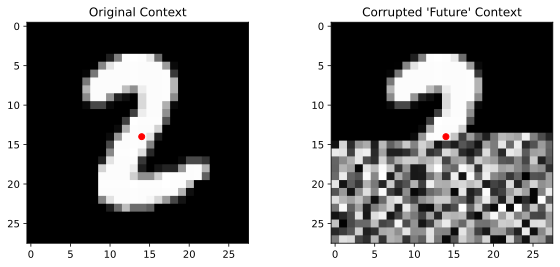

--- Proof of Causal Blindness ---
Total difference in probability distributions: 0.00000000
Conclusion: The model's prediction for (14,14) is EXACTLY the same.
The network physically cannot condition on pixels below and to the right!


In [36]:
@torch.no_grad()
def prove_blindness_to_future(model, dataloader, device):
    model.eval()

    # 1. Grab a single real image
    imgs, _ = next(iter(dataloader))
    real_img = imgs[0:1].to(device).clone()

    # 2. Create a modified copy where we destroy everything below and to the right
    # by filling it with random noise (or any other value)
    corrupted_img = real_img.clone()

    # Target pixel is (14, 14)
    target_h, target_w = 14, 14

    # Corrupt all rows below 14
    corrupted_img[:, :, target_h+1:, :] = torch.randint(0, 256, (1, 1, 28-(target_h+1), 28)).float().to(device)
    # Corrupt all pixels to the right of 14 in the 14th row
    corrupted_img[:, :, target_h, target_w+1:] = torch.randint(0, 256, (1, 1, 1, 28-(target_w+1))).float().to(device)

    # 3. Forward pass for BOTH images
    logits_real = model(real_img)
    logits_corrupted = model(corrupted_img)

    # 4. Extract probabilities for the middle pixel (14, 14)
    probs_real = F.softmax(logits_real[0, :, 0, target_h, target_w], dim=-1).cpu().numpy()
    probs_corrupted = F.softmax(logits_corrupted[0, :, 0, target_h, target_w], dim=-1).cpu().numpy()

    # 5. Check if the distributions are exactly identical
    difference = abs(probs_real - probs_corrupted).sum()

    # --- Plotting to show the professor ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(real_img[0, 0].cpu().numpy(), cmap='gray')
    axes[0].set_title("Original Context")
    axes[0].plot(target_w, target_h, 'ro')

    axes[1].imshow(corrupted_img[0, 0].cpu().numpy(), cmap='gray')
    axes[1].set_title("Corrupted 'Future' Context")
    axes[1].plot(target_w, target_h, 'ro')

    plt.show()

    print("--- Proof of Causal Blindness ---")
    print(f"Total difference in probability distributions: {difference:.8f}")
    if difference < 1e-6:
        print("Conclusion: The model's prediction for (14,14) is EXACTLY the same.")
        print("The network physically cannot condition on pixels below and to the right!")

# Run this using your pretrained model
prove_blindness_to_future(pretrained_model, val_loader, device)

### ***another solution***

### 3(d) The conditional probability of the middle pixel, given the values of all pixels below and to the right of it.

**Classification: HARD**

**1. Architectural Constraint (Causal Blindness)**
Autoregressive models like PixelCNN are strictly unidirectional by design. The network models the joint distribution of an image by factorizing it into a product of conditional probabilities: $P(x_i \mid x_{<i})$. Due to the causal masking mechanism (Mask Types A and B), the network's receptive field for a given target pixel is strictly restricted to the pixels above and to the left of it. Consequently, the model is architecturally "blind" to any pixels located below or to the right of the target. It cannot natively evaluate $P(x_{14,14} \mid x_{>14,14})$.

**2. Computational Intractability of Exact Inference**
To calculate this probability exactly, we would need to use Bayes' Theorem and marginalize over all possible states of the unobserved "past" pixels ($x_{<14,14}$):
$$P(x_{mid}=c \mid x_{future}) \propto \sum_{x_{past}} P(x_{mid}=c, x_{future} \mid x_{past}) \cdot P(x_{past})$$
Summing over $256^{405}$ past combinations is computationally intractable. 

**3. Approximation Method (Monte Carlo + Likelihood Evaluation)**
Since exact inference is too costly, we approximate the distribution using a single sampled context:

* **Step 1 (Sample a Past):** Use the model autoregressively to generate a single, highly-probable valid "past" context ($x_{past}^*$).
* **Step 2 (Hypothesis Generation):** Combine this sampled past with the *given* real future context to create a batch of 256 composite images. Inject a unique intensity value $c \in [0, 255]$ into the middle pixel of each image across the batch, creating 256 parallel hypotheses.
* **Step 3 (Likelihood Evaluation):** Pass the entire batch of 256 hypotheses through the model simultaneously. For each color hypothesis $c$, calculate the sum of the Cross-Entropy loss (negative log-likelihood) strictly over the middle pixel and all future pixels:
$$L_c = - \sum_{i \ge mid} \log P(x_i \mid x_{<i}^{(c)})$$
Where $x_{<i}^{(c)}$ is the specific causal context for pixel $i$ under hypothesis $c$. This loss $L_c$ acts as a measure of "surprise"—quantifying how statistically unlikely the future sequence is, given the specific color $c$ injected into the middle pixel.
* **Step 4 (Normalization):** To translate these 256 loss values ($L_0 \dots L_{255}$) back into a valid probability distribution, we negate them to restore the log-likelihoods and apply the Softmax function. This exponentiates and normalizes the scores so they sum exactly to 1.0:
$$P(x_{mid}=c \mid x_{future}) \approx \text{Softmax}(-L_c) = \frac{\exp(-L_c)}{\sum_{v=0}^{255} \exp(-L_v)}$$

### 3(d) The Conditional Probability of the Middle Pixel, Given the Future

**The Objective:** Calculate $P(x_{mid} \mid x_{>mid})$ — the probability of the middle pixel, given only the values of all pixels below and to the right of it.

**The Architectural Challenge (Causal Blindness):** 
Autoregressive models like PixelCNN are strictly unidirectional. They factorize the joint probability of an image as $P(X) = \prod P(x_i \mid x_{<i})$. Due to the causal masking mechanism, the network is architecturally "blind" to any pixels located below or to the right of the target. It cannot natively evaluate a pixel based on its future. 

To solve this, we must use a **Monte Carlo approximation combined with Likelihood Evaluation**. Here is the deep dive into exactly how and why this works.

---

#### Step 1: Generating the "Past" (Filling the Missing Context)
Because the model is causal, it *must* look backward to function. We cannot simply feed it the future and ask it to predict the middle, because the math requires the preceding pixels ($x_{<mid}$). 

Since we are not given the real past, we use the model itself to generate a highly probable, statistically valid "past" context. We run the model autoregressively from pixel 0 up to the pixel just before the middle, creating a sampled past ($x_{past}^*$). 

#### Step 2: Formulating 256 Hypotheses
Now that we have a generated past and a real given future, the only unknown is the middle pixel itself. Because pixel intensities are discrete, it can only take one of 256 possible values ($0, 1, \dots, 255$).

We create a batch of 256 identical cloned images. In each clone, the past and the future are exactly the same, but we inject a unique intensity value $c \in [0, 255]$ into the middle pixel. We now have 256 parallel "hypotheses" representing every possible reality for that pixel.

#### Step 3: The "Future as a Jury" (Likelihood Evaluation)
We pass all 256 hypotheses through the PixelCNN simultaneously. For each hypothesis $c$, we calculate the Negative Log-Likelihood (Cross-Entropy loss) strictly over the middle pixel *and* all the future pixels:

$$L_c = - \sum_{i \ge mid} \log P(x_i \mid x_{<i}^{(c)})$$

**Why does this work?** This is the core "magic" of the algorithm. By the chain rule of probability, changing the color of the middle pixel directly alters the conditional probability of all subsequent future pixels. 

The future pixels act as a jury. If we inject a completely illogical color into the middle pixel (for example, a bright white pixel in the middle of a continuous dark stroke), the model will assign a massive penalty (high loss) to the future pixels, because a dark future logically shouldn't follow a bright white past. 

Conversely, the hypothesis $c$ that perfectly bridges the generated past and the real future will yield the lowest total "surprise" (loss).

#### Step 4: Normalization (From Loss to Probability)
After Step 3, we have 256 loss values ($L_0 \dots L_{255}$). To translate these raw loss penalties back into a valid probability distribution (where all values are between 0 and 1 and sum to 1.0), we:
1. **Negate the loss:** To convert the Negative Log-Likelihood back into a positive Log-Likelihood.
2. **Apply Softmax:** This exponentiates the scores and normalizes them.

$$P(x_{mid}=c \mid x_{future}) \approx \text{Softmax}(-L_c) = \frac{\exp(-L_c)}{\sum_{v=0}^{255} \exp(-L_v)}$$

The resulting vector is our final probability distribution for the middle pixel.



---
### Mathematical Proof: Probability of the Middle Pixel Given the Future

Here is the complete, step-by-step mathematical proof for how we derive that equation.

To keep the notation clean, let's define our variables:

* **$x_{mid}$**: The middle pixel we are trying to predict.
* **$c$**: A specific color intensity value where $c \in \{0, 1, \dots, 255\}$.
* **$x_{future}$**: All pixels that come after the middle pixel.
* **$x_{past}$**: All pixels that come before the middle pixel.

---

#### Step 1: The Monte Carlo Approximation (Handling the Missing Past)

We want to find the probability of the middle pixel given only the future: $P(x_{mid}=c \mid x_{future})$.

However, an autoregressive model strictly evaluates probabilities conditioned on the past. To bridge this gap, we rely on the sampled past we generated, denoted as $x_{past}^*$. By assuming our generated past is a highly representative sample of the true distribution, we make a Monte Carlo approximation (with a sample size of 1):

$$P(x_{mid}=c \mid x_{future}) \approx P(x_{mid}=c \mid x_{future}, x_{past}^*)$$

*This approximation is exactly where the $\approx$ symbol in your equation comes from.*

#### Step 2: Definition of Conditional Probability

Using the standard probability rule $P(A \mid B, C) = \frac{P(A, B \mid C)}{P(B \mid C)}$, we can rewrite the conditional probability of the middle pixel as the ratio of a joint probability to a marginal probability:

$$P(x_{mid}=c \mid x_{future}, x_{past}^*) = \frac{P(x_{mid}=c, x_{future} \mid x_{past}^*)}{P(x_{future} \mid x_{past}^*)}$$

Let's call the numerator **$P_{joint}(c)$**. This is the probability of hypothesis $c$ and the future co-occurring, given the past.

#### Step 3: The Autoregressive Factorization (Chain Rule)

Because this is an autoregressive model, the joint probability of a sequence of pixels is just the product of their individual conditional probabilities. We can expand the numerator $P_{joint}(c)$ using the chain rule of probability:

$$P_{joint}(c) = P(x_{mid}=c \mid x_{past}^*) \prod_{i > mid} P(x_i \mid x_{<i}^{(c)})$$

*(Note: $x_{<i}^{(c)}$ simply means the sequence of all pixels preceding pixel $i$, where the middle pixel has been explicitly set to our hypothesis color $c$.)*

#### Step 4: Translating Loss to Likelihood

Now, let's look at how the Cross-Entropy loss ($L_c$) is calculated for this exact sequence in PyTorch. The loss over the middle and future pixels is the sum of the negative log-likelihoods:

$$L_c = - \left( \log P(x_{mid}=c \mid x_{past}^*) + \sum_{i > mid} \log P(x_i \mid x_{<i}^{(c)}) \right)$$

According to the laws of logarithms ($\log A + \log B = \log(A \cdot B)$), the sum of the logs is equal to the log of the product:

$$L_c = - \log \left( P(x_{mid}=c \mid x_{past}^*) \prod_{i > mid} P(x_i \mid x_{<i}^{(c)}) \right)$$

Notice that the expression inside the logarithm is exactly the $P_{joint}(c)$ we defined in Step 3! Therefore:

$$L_c = - \log P_{joint}(c)$$

By exponentiating both sides to solve for $P_{joint}(c)$, we get:

$$P_{joint}(c) = \exp(-L_c)$$

#### Step 5: The Law of Total Probability (The Denominator)

We now need to solve for the denominator from Step 2: $P(x_{future} \mid x_{past}^*)$.

According to the Law of Total Probability, to find the probability of the future, we must sum up the joint probabilities across all mutually exclusive, possible states of the middle pixel (which are the 256 color values, $v$):

$$P(x_{future} \mid x_{past}^*) = \sum_{v=0}^{255} P(x_{mid}=v, x_{future} \mid x_{past}^*)$$

Since the term inside the sum is just $P_{joint}(v)$, we can substitute the result we found in Step 4:

$$P(x_{future} \mid x_{past}^*) = \sum_{v=0}^{255} \exp(-L_v)$$

#### Step 6: The Final Substitution

Finally, we substitute our solved numerator (Step 4) and our solved denominator (Step 5) back into the main equation from Step 2:

$$P(x_{mid}=c \mid x_{future}, x_{past}^*) = \frac{\exp(-L_c)}{\sum_{v=0}^{255} \exp(-L_v)}$$

This equation—exponentiating a specific value and dividing it by the sum of all exponentiated values—is the precise mathematical definition of the **Softmax** function applied to the vector of negative losses.

Thus, the proof is complete:

$$P(x_{mid}=c \mid x_{future}) \approx \text{Softmax}(-L_c)$$

Step 1: Sampling a valid 'past' context... (takes a few seconds)


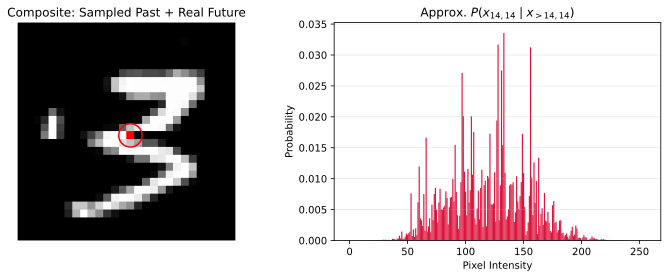

Approximated most likely color is 133 (Prob: 0.0336)


In [49]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def approx_conditional_given_future(model, dataloader, device):
    model.eval()
    
    # 1. Get a real image to serve as the "known future"
    imgs, _ = next(iter(dataloader))
    real_img = imgs[0:1].to(device)
    
    # STEP 1: Sample a valid "past" context
    # Generating x_past* (a single highly probable sequence for x < 14,14)
    print("Step 1: Sampling a valid 'past' context... (takes a few seconds)")
    sampled_img = torch.zeros((1, 1, 28, 28), dtype=torch.long).to(device) - 1
    for h in range(15):
        for w in range(28):
            if h == 14 and w >= 14:
                break # Stop right before the middle pixel
            pred = model(sampled_img[:, :, :h+1, :])
            probs = F.softmax(pred[:, :, 0, h, w], dim=-1)
            sampled_img[:, 0, h, w] = torch.multinomial(probs, 1).squeeze(-1)
            
    # STEP 2: Create a batch of 256 hypotheses
    batch_imgs = torch.zeros((256, 1, 28, 28), dtype=torch.float32).to(device)
    
    # Copy the sampled past and the real future into all 256 images
    batch_imgs[:, :, :14, :] = sampled_img[:, :, :14, :].float()
    batch_imgs[:, :, 14, :14] = sampled_img[:, :, 14, :14].float()
    batch_imgs[:, :, 14, 15:] = real_img[:, :, 14, 15:]
    batch_imgs[:, :, 15:, :] = real_img[:, :, 15:, :]
    
    # Inject the 256 possible colors into the middle pixel
    # This represents creating the 256 parallel hypotheses for c in [0, 255]
    batch_imgs[:, 0, 14, 14] = torch.arange(256, dtype=torch.float32).to(device)
    
    # STEP 3: Likelihood Evaluation
    # Equation: L_c = - \sum_{i >= mid} \log P(x_i | x_{<i}^{(c)})
    logits = model(batch_imgs)
    targets = batch_imgs.long()
    
    # Calculate the negative log-likelihood: - \log P(x_i | x_{<i}^{(c)}) for ALL pixels
    nll_per_pixel = F.cross_entropy(logits, targets, reduction='none')
    
    # Mask to isolate the condition (i >= mid). We only care about the middle and future pixels.
    mask = torch.zeros((1, 28, 28)).to(device)
    mask[0, 14, 14:] = 1.0
    mask[0, 15:, :] = 1.0
    
    # Sum the NLL over the masked region to get the final L_c for each of the 256 images
    nll_future = (nll_per_pixel * mask).sum(dim=(1, 2, 3))
    
    # STEP 4: Normalization to Probability Distribution
    # Equation: P(x_mid = c | x_future) ≈ Softmax(-L_c)
    # We negate nll_future to restore the log-likelihoods, then apply Softmax.
    approx_probs = F.softmax(-nll_future, dim=0).cpu().numpy()
    
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Get the image as a numpy array (values 0-255)
    vis_img = batch_imgs[128, 0].cpu().numpy().copy()
    
    # Convert grayscale to RGB by stacking the array 3 times and normalizing to [0, 1]
    vis_img_rgb = np.stack([vis_img / 255.0]*3, axis=-1)
    
    # Color the middle pixel RED (R=1.0, G=0.0, B=0.0)
    vis_img_rgb[14, 14] = [1.0, 0.0, 0.0]
    
    ax1.imshow(vis_img_rgb)
    ax1.set_title("Composite: Sampled Past + Real Future")
    ax1.axis('off')
    
    # Add a small red circle around it just to make it easier to spot
    circle = plt.Circle((14, 14), 1.5, color='red', fill=False, linewidth=1.5)
    ax1.add_patch(circle)
    
    # Bar chart for probabilities
    ax2.bar(range(256), approx_probs, color='crimson', width=1.0)
    ax2.set_title("Approx. $P(x_{14,14} \mid x_{>14,14})$")
    ax2.set_xlabel("Pixel Intensity")
    ax2.set_ylabel("Probability")
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    most_likely_val = approx_probs.argmax()
    print(f"Approximated most likely color is {most_likely_val} (Prob: {approx_probs[most_likely_val]:.4f})")

# Execute the approximation
approx_conditional_given_future(pretrained_model, val_loader, device)

___
## e) The conditional probability of the middle pixel, given the values of all other pixels in the image.
___

# PixelCNN: Exact Bayesian Inference for a Single Missing Pixel

## Overview
This section addresses the evaluation of the conditional probability of a target pixel given the complete context of *all* other pixels in the image, both past and future: $P(x_{14,14} \mid x_{\neq 14,14})$. 

While seemingly intractable at first glance due to the unidirectional nature of the PixelCNN, this specific scenario is elegantly solvable. Because only a single discrete variable (one pixel) is unknown, we can leverage Bayes' Theorem to compute the exact probability distribution.

## 1. Theoretical Foundation (Bayes' Theorem)
As established, PixelCNN naturally models $P(x_i \mid x_{<i})$ and cannot inherently condition on future pixels. However, unlike attempting to guess an entire missing half of an image (which has a state space of $256^{392}$), we are only missing *one* pixel with exactly 256 possible states (intensities 0–255). 

We can compute the exact conditional probability using the definition of conditional probability and Bayes' Theorem:

$$P(x_{14,14} = c \mid x_{\neq 14,14}) = \frac{P(\text{Full Image with middle pixel = } c)}{\sum_{v=0}^{255} P(\text{Full Image with middle pixel = } v)}$$

## 2. Key Insight: Leveraging "Future" Context
The brilliance of this approach lies in the causal chain. Modifying the value of the middle pixel does not merely change its own isolated probability; it fundamentally alters the conditional probability of **all subsequent pixels** (the entire bottom-right half of the image). 

If we hypothesize that the middle pixel is white, but the subsequent pixels exhibit patterns characteristic of a black background, the network will assign a severely low probability to those future pixels, subsequently penalizing the total joint probability of that specific image hypothesis. In essence, the "future" pixels are allowed to cast a vote on the validity of the middle pixel.

## 3. Algorithmic Implementation
To evaluate this efficiently in practice, we compute the joint probability of all 256 possible realities simultaneously:

1. **Batch Generation:** Create a batch of 256 identical copies of the context image.
2. **Hypothesis Injection:** Systematically alter the middle pixel across the batch such that copy `0` has a target pixel value of `0`, copy `1` has a value of `1`, and so on up to `255`.
3. **Total Likelihood Evaluation:** Pass all 256 images through the PixelCNN and calculate the Total Log-Probability (negative sum of cross-entropy losses) for each complete image.
4. **Distribution Normalization:** Apply a Softmax function over these 256 total log-probabilities to yield the exact conditional distribution.

Given ALL other pixels (past and future), the highest probability (1.0000) is for color 252.
The actual true color was 252.


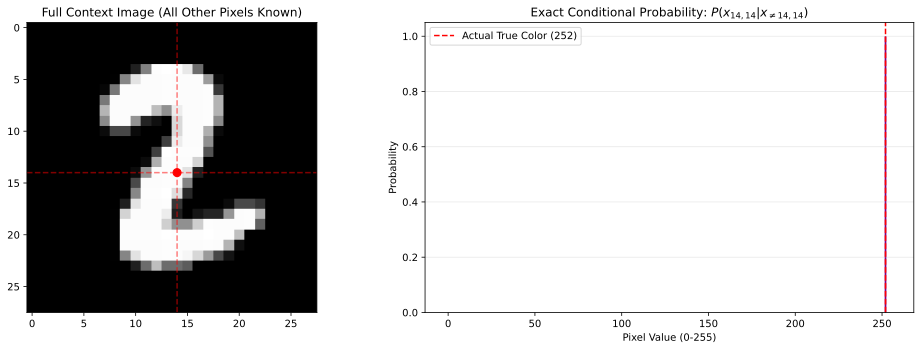

In [37]:
@torch.no_grad()
def plot_full_conditional_prob(model, dataloader, device):
    model.eval()

    # 1. Grab a single real image
    imgs, _ = next(iter(dataloader))
    real_img = imgs[0:1].to(device) # Shape: [1, 1, 28, 28]

    actual_middle_color = real_img[0, 0, 14, 14].item()
    target_h, target_w = 14, 14

    # 2. Create 256 copies of this image
    # Shape: [256, 1, 28, 28]
    batch_imgs = real_img.repeat(256, 1, 1, 1)

    # 3. Set the middle pixel of each copy to a different value (0 to 255)
    # Copy 0 gets color 0, Copy 1 gets color 1, etc.
    batch_imgs[:, 0, target_h, target_w] = torch.arange(256, dtype=torch.float32).to(device)

    # 4. Forward pass for all 256 iat once
    logits = model(batch_imgs) # Shape: [256, 256, 1, 28, 28]mages

    # 5. Calculate the Negative Log-Likelihood (NLL) for every single pixel in all 256 images
    targets = batch_imgs.long()
    # Using reduction='none' gives us the loss per pixel: Shape [256, 1, 28, 28]
    nll_per_pixel = F.cross_entropy(logits, targets, reduction='none')

    # 6. Sum the NLL across the entire image to get the Total NLL for each of the 256 images
    # Shape: [256]
    total_nll_per_image = nll_per_pixel.sum(dim=(1, 2, 3))

    # Log Probability is just negative NLL
    log_probs_per_image = -total_nll_per_image

    # 7. Apply Softmax to these 256 Log-Probabilities to get the exact conditional distribution
    exact_probs = F.softmax(log_probs_per_image, dim=0).cpu().numpy()

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Context Image
    ax1.imshow(real_img[0, 0].cpu().numpy(), cmap='gray')
    ax1.axhline(y=14, color='red', linestyle='--', alpha=0.5)
    ax1.axvline(x=14, color='red', linestyle='--', alpha=0.5)
    ax1.plot(14, 14, 'ro', markersize=8)
    ax1.set_title("Full Context Image (All Other Pixels Known)")

    # Plot 2: Exact Probability Distribution
    ax2.bar(range(256), exact_probs, color='purple', width=1.0)
    ax2.axvline(x=actual_middle_color, color='red', linestyle='--', label=f'Actual True Color ({int(actual_middle_color)})')
    ax2.set_title("Exact Conditional Probability: $P(x_{{14,14}} | x_{{\\neq 14,14}})$")
    ax2.set_xlabel("Pixel Value (0-255)")
    ax2.set_ylabel("Probability")
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    most_likely_val = exact_probs.argmax()
    print(f"Given ALL other pixels (past and future), the highest probability ({exact_probs[most_likely_val]:.4f}) is for color {most_likely_val}.")
    print(f"The actual true color was {int(actual_middle_color)}.")

    plt.tight_layout()
    plt.show()

# Run this using your pretrained model
plot_full_conditional_prob(pretrained_model, val_loader, device)

___
## f) Samples of the bottom half of an image, given the top half of an image.
___

# PixelCNN: Conditional Generation (Image Inpainting)

## Overview
This section explores the generation of the bottom half of an image strictly conditioned on the known top half: sampling $x_{>405} \sim P(x_{>405} \mid x_{\leq 405})$. 

Unlike querying the network for the probability of future events (which requires workarounds), generating future events based on past context is exactly what the autoregressive architecture is designed to perform natively. This process is commonly referred to as image inpainting or completion.

## 1. Theoretical Foundation (Native Autoregression)
The generative process of a PixelCNN relies on factoring the joint probability distribution of the image sequentially: 

$$P(X) = \prod_{i=1}^{N} P(x_i \mid x_{<i})$$

In an unconditional generation task, sampling begins from an empty canvas at index $i=1$ ($h=0, w=0$). However, if a valid image prefix (the top half, representing $x_1$ through $x_{405}$) is already provided, the model can simply bypass the generation of these initial pixels. The sampling process strictly initializes at index $i=406$ (row 14, column 14, or row 14 column 0 if replacing the entire bottom half).

## 2. Receptive Field and Context Integration
During the generation of the bottom half, the spatial location of the current target pixel naturally places the provided top half within the network's valid causal receptive field. 

As the model samples a new pixel row-by-row, its predictions are conditioned upon both the fixed, true pixels from the original top half *and* the newly generated pixels in the preceding rows of the bottom half. This continuous integration of known context ensures that the generated completion smoothly transitions from and logically concludes the morphological structures (e.g., the loops or stems of a handwritten digit) established in the upper hemisphere.

## 3. Algorithmic Implementation
The generation procedure bypasses the first half of the canvas and loops only over the unknown bottom region:

1. **Context Initialization:** Extract real images from the dataset and securely mask the bottom half (e.g., using a sentinel value like `-1` to denote ungenerated space).
2. **Targeted Autoregressive Loop:** Initiate the generation loop exclusively over the missing spatial coordinates (rows 14 through 27).
3. **Sequential Forward Passes:** At each spatial coordinate $(h, w)$, perform a forward pass. To optimize computation, the forward pass need only process the tensor up to the current row, as future rows are causally masked and do not influence the current prediction.
4. **Probabilistic Sampling:** Extract the probability distribution for the current pixel, apply a Softmax, and sample the intensity value using a multinomial distribution. Insert this generated value into the canvas before progressing to the next spatial coordinate.

Generating bottom half:   0%|          | 0/14 [00:00<?, ?it/s]

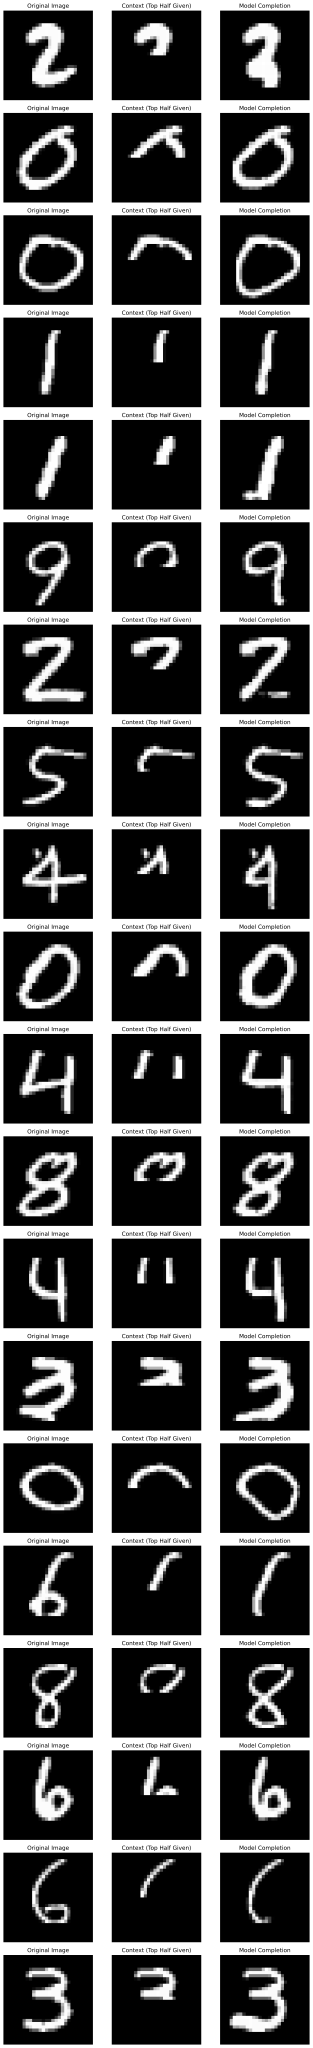

In [41]:
@torch.no_grad()
def generate_bottom_half(model, dataloader, device, num_images=4):
    model.eval()
    
    # 1. Grab a batch of real images
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:num_images].to(device) # Shape: [num_images, 1, 28, 28]
    
    # 2. Create the context images by masking the bottom half
    # We use -1 to represent "unknown" pixels that need to be generated
    context_imgs = real_imgs.clone()
    target_row = 14
    context_imgs[:, :, target_row:, :] = -1
    
    # We will operate on a copy to keep the original context for visualization
    gen_imgs = context_imgs.clone()
    
    # 3. Autoregressive Generation Loop
    # We ONLY loop over the unknown pixels (row 14 and below)
    for h in tqdm(range(target_row, 28), desc="Generating bottom half"):
        for w in range(28):
            # Forward pass through the network with the current state of the image
            # We only need to pass the image up to the current row to save computation
            pred = model(gen_imgs[:, :, :h+1, :])
            
            # Extract the probability distribution for the current pixel (h, w) across all images in the batch
            probs = F.softmax(pred[:, :, 0, h, w], dim=-1)
            
            # Sample a color based on the distribution
            sampled_colors = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
            
            # Update the generated image with the new pixels
            gen_imgs[:, 0, h, w] = sampled_colors

    # --- Plotting the Results ---
    fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))
    
    for i in range(num_images):
        # Original Image
        ax = axes[i, 0] if num_images > 1 else axes[0]
        ax.imshow(real_imgs[i, 0].cpu().numpy(), cmap='gray')
        ax.set_title("Original Image")
        ax.axis('off')
        
        # Context (Top Half)
        ax = axes[i, 1] if num_images > 1 else axes[1]
        # Replace the -1 unknown values with 0 (black) just for visualization
        vis_context = context_imgs[i, 0].cpu().numpy().copy()
        vis_context[vis_context == -1] = 0
        ax.imshow(vis_context, cmap='gray')
        ax.set_title("Context (Top Half Given)")
        ax.axis('off')
        
        # Generated Result
        ax = axes[i, 2] if num_images > 1 else axes[2]
        ax.imshow(gen_imgs[i, 0].cpu().numpy(), cmap='gray')
        ax.set_title("Model Completion")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the completion function
generate_bottom_half(pretrained_model, val_loader, device, num_images=20)

___
## g) Samples of the top half of an image, given the bottom half of an image
___

# PixelCNN: Intractability of Reverse Conditional Generation (Upward Inpainting)

## Overview
This section addresses the inverse of the previous problem: generating the *top* half of an image given the *bottom* half. Mathematically, this requires sampling from the conditional distribution $P(x_{\leq 405} \mid x_{>405})$. 

Unlike generating the bottom half (which aligns perfectly with the model's natural top-to-bottom sequence), generating the top half given the bottom half explicitly violates the causal direction of the standard PixelCNN architecture.

## 1. Architectural Constraint (Strict Causality)
As established in Part (d), a standard PixelCNN is strictly unidirectional. Its fundamental equation, $P(X) = \prod_{i=1}^{N} P(x_i \mid x_{<i})$, forces information to flow exclusively from past pixels to future pixels (top-left to bottom-right).

When attempting to generate the top half of an image, the model natively has no mechanism to "look ahead" or condition its predictions on the known bottom half. The convolutional masks (Type A and B) physically prevent gradients or features from the bottom rows from flowing upward into the predictions of the top rows.

## 2. Computational Intractability
To force the current forward-trained model to evaluate this, we would have to use Bayes' Theorem. However, because we are trying to *generate* the missing 392 pixels of the top half, we would need to evaluate the joint probability of the bottom half against every single possible combination of the top half to find the most likely prefix.

Since there are 392 missing pixels, each with 256 possible colors, the state space is $256^{392}$. Searching or marginalizing over this space to perform generation is mathematically and computationally intractable. 

## 3. The Practical Solution: Bidirectional Modeling
In the industry, when models are required to complete images in arbitrary directions (or fill in arbitrary holes), researchers use **Bidirectional PixelCNNs** or train specific reverse models. 

To solve this specific problem efficiently in a single pass, one must train a secondary, independent PixelCNN model on a dataset where all images are flipped upside down (rotated 180 degrees). 
1. The bottom half of the original image becomes the "top half" of the reversed image.
2. The reverse model performs native downward autoregression (just like Part f).
3. The generated image is flipped back to its original orientation.

In [ ]:
@torch.no_grad()
def generate_top_half_with_reverse_model(reversed_model, dataloader, device, num_images=4):
    """
    NOTE: This requires 'reversed_model', a PixelCNN trained on 180-degree rotated images.
    Our standard 'pretrained_model' will output gibberish if used here.
    """
    reversed_model.eval()
    
    # 1. Grab a batch of real images
    real_imgs, _ = next(iter(dataloader))
    real_imgs = real_imgs[:num_images].to(device)
    
    # 2. Mask the top half of the original image (-1 represents unknown)
    context_imgs = real_imgs.clone()
    target_row = 14
    context_imgs[:, :, :target_row, :] = -1 
    
    # 3. CRITICAL STEP: Rotate the images 180 degrees (flip both Height and Width)
    # Now, the known bottom half physically sits at the top of the tensor!
    flipped_imgs = torch.flip(context_imgs, dims=[2, 3])
    
    # 4. Standard Autoregressive Generation (Identical to Part f, but on flipped images)
    gen_imgs = flipped_imgs.clone()
    for h in tqdm(range(target_row, 28), desc="Generating (Reversed)"):
        for w in range(28):
            pred = reversed_model(gen_imgs[:, :, :h+1, :])
            probs = F.softmax(pred[:, :, 0, h, w], dim=-1)
            sampled_colors = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
            gen_imgs[:, 0, h, w] = sampled_colors

    # 5. Restore original orientation by flipping 180 degrees again
    final_restored_imgs = torch.flip(gen_imgs, dims=[2, 3])

    # --- Plotting the Results ---
    fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))
    for i in range(num_images):
        # Original Image
        ax = axes[i, 0] if num_images > 1 else axes[0]
        ax.imshow(real_imgs[i, 0].cpu().numpy(), cmap='gray')
        ax.set_title("Original Image")
        ax.axis('off')
        
        # Context (Bottom Half Given)
        ax = axes[i, 1] if num_images > 1 else axes[1]
        vis_context = context_imgs[i, 0].cpu().numpy().copy()
        vis_context[vis_context == -1] = 0
        ax.imshow(vis_context, cmap='gray')
        ax.set_title("Context (Bottom Half)")
        ax.axis('off')
        
        # Generated Result (from reverse model)
        ax = axes[i, 2] if num_images > 1 else axes[2]
        ax.imshow(final_restored_imgs[i, 0].cpu().numpy(), cmap='gray')
        ax.set_title("Reverse Model Completion")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

- - - 
## Another solution
- - -

**Classification: HARD**

**1. The Symmetrical Problem (Predicting the Past)**
Unlike part (f), this task asks us to sample the "past" (top half, $x_{<14}$) conditioned entirely on the "future" (bottom half, $x_{\ge 14}$). Because PixelCNN is an autoregressive causal model, it can only naturally sample forwards. Natively sampling the top half conditioned on the bottom half is architecturally impossible in a single forward pass.

**2. The Mathematical Foundation (Bayes' Theorem & Importance Sampling)**
We want to sample from the posterior distribution: $P(X_{top} \mid X_{bottom})$.
Using Bayes' theorem, this is proportional to:
$$P(X_{top} \mid X_{bottom}) \propto P(X_{bottom} \mid X_{top}) \cdot P(X_{top})$$

To approximate sampling from this intractable distribution, we can use a method inspired by **Sampling Importance Resampling (SIR)**:
1. **$P(X_{top})$ [The Prior]:** We can natively sample valid top halves using standard ancestral sampling, totally blind to the bottom half.
2. **$P(X_{bottom} \mid X_{top})$ [The Likelihood]:** Once we have a proposed top half, we can attach the known bottom half and evaluate how "likely" this specific future is, given our proposed past.

**3. Algorithmic Steps**
* **Step 1 (Generate Proposals):** Unconditionally sample a large batch (e.g., $N=64$) of valid top halves using the model's standard autoregressive generation. These are our hypotheses.
* **Step 2 (Attach Future):** Take the real given bottom half and append it to all 64 generated top halves to create 64 complete composite images.
* **Step 3 (Likelihood Evaluation):** Pass the entire batch through the model. Calculate the Cross-Entropy loss (NLL) *strictly* over the bottom half. This loss acts as a penalty: a top half that logically flows into the real bottom half will yield a low loss.
* **Step 4 (Resampling):** Negate the losses and apply Softmax to turn them into importance weights (probabilities). Sample from these 64 composite images based on these weights to select the most statistically sound top halves.

Step 1: Generating 64 independent proposals for the top half...
(This will take about 10-20 seconds as it samples autoregressively)
Step 2: Attaching the known bottom half to all proposals...
Step 3: Evaluating likelihoods to find the best matching top halves...
Done! Plotting the results...


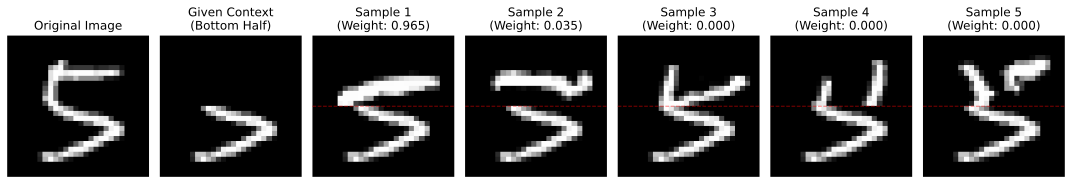

In [50]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def sample_top_given_bottom(model, dataloader, device, num_proposals=64, num_samples_to_show=5):
    model.eval()
    
    # 1. Get a real image to serve as the context (The Bottom Half)
    imgs, _ = next(iter(dataloader))
    real_img = imgs[0:1].to(device)
    
    print(f"Step 1: Generating {num_proposals} independent proposals for the top half...")
    print("(This will take about 10-20 seconds as it samples autoregressively)")
    
    # Create a batch to hold our proposals
    batch_imgs = torch.zeros((num_proposals, 1, 28, 28), dtype=torch.float32).to(device)
    
    # Sample the top half (rows 0 to 13) UNCONDITIONALLY (The Prior)
    for h in range(14):
        for w in range(28):
            logits = model(batch_imgs)
            probs = F.softmax(logits[:, :, 0, h, w], dim=-1)
            sampled_pixels = torch.multinomial(probs, 1).squeeze(-1)
            batch_imgs[:, 0, h, w] = sampled_pixels.float()
            
    print("Step 2: Attaching the known bottom half to all proposals...")
    # Inject the known condition (the real bottom half) into all samples
    batch_imgs[:, :, 14:, :] = real_img[:, :, 14:, :].float()
    
    print("Step 3: Evaluating likelihoods to find the best matching top halves...")
    # Evaluate the entire batch
    logits = model(batch_imgs)
    targets = batch_imgs.long()
    
    # Calculate NLL per pixel
    nll_per_pixel = F.cross_entropy(logits, targets, reduction='none')
    
    # Mask: We ONLY care about the likelihood of the BOTTOM half
    mask = torch.zeros((1, 28, 28)).to(device)
    mask[0, 14:, :] = 1.0
    
    # Sum NLL over the bottom half for each of the 64 images
    nll_bottom = (nll_per_pixel * mask).sum(dim=(1, 2, 3))
    
    # Step 4: Resampling based on likelihood
    # Convert NLL to probability weights
    weights = F.softmax(-nll_bottom, dim=0)
    
    # Sample the best indices based on these weights
    # (Choosing the top halves that make the bottom half most likely)
    best_indices = torch.multinomial(weights, num_samples_to_show, replacement=False)
    
    print("Done! Plotting the results...")
    
    # --- Plotting ---
    fig, axes = plt.subplots(1, num_samples_to_show + 2, figsize=(15, 3))
    
    # Plot Original Full Image
    axes[0].imshow(real_img[0, 0].cpu().numpy(), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # Plot The Given Context (Bottom Half only)
    bottom_half_vis = real_img[0, 0].cpu().numpy().copy()
    bottom_half_vis[:14, :] = 0 # Black out the top half
    axes[1].imshow(bottom_half_vis, cmap='gray')
    axes[1].set_title("Given Context\n(Bottom Half)")
    axes[1].axis('off')
    
    # Plot the selected best samples
    for i, idx in enumerate(best_indices):
        idx_val = idx.item()
        prob = weights[idx_val].item()
        axes[i+2].imshow(batch_imgs[idx_val, 0].cpu().numpy(), cmap='gray')
        axes[i+2].set_title(f"Sample {i+1}\n(Weight: {prob:.3f})")
        axes[i+2].axis('off')
        
        # Add a subtle red line to separate generated top from real bottom
        axes[i+2].axhline(y=13.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
    plt.tight_layout()
    plt.show()

# Execute the sampling process
sample_top_given_bottom(pretrained_model, val_loader, device)